Generating synthetic audio samples...
Extracting Audio Features (MFCC)...
Clustering Audio...
Silhouette Score: 0.6738


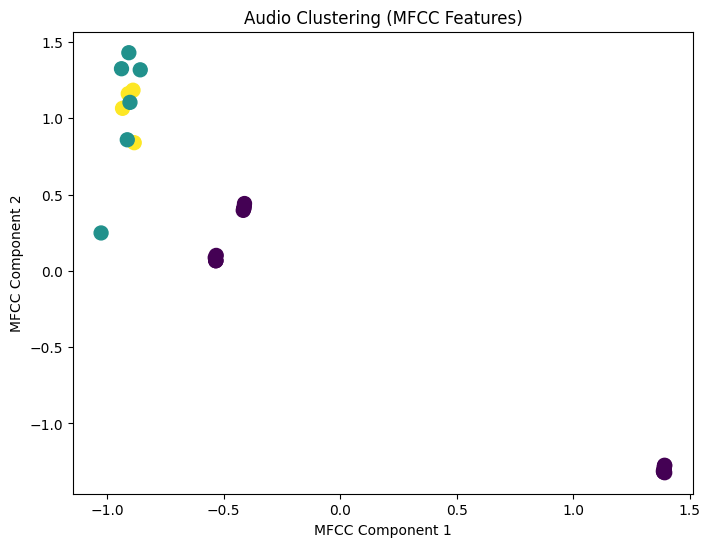

In [1]:


!pip install librosa --quiet

import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import soundfile as sf
import os

# --- 1. Data Generation ---

print("Generating synthetic audio samples...")
sr = 22050
duration = 2 # seconds
n_samples = 30
audio_data = []

def generate_tone(freq=100):
    t = np.linspace(0, duration, int(sr * duration))
    return 0.5 * np.sin(2 * np.pi * freq * t)

def generate_noise():
    return 0.1 * np.random.normal(0, 1, int(sr * duration))

def generate_pulse(bpm=120):
    t = np.linspace(0, duration, int(sr * duration))
    signal = np.zeros_like(t)
    interval = int(sr * 60 / bpm)
    for i in range(0, len(signal), interval):
        if i+1000 < len(signal):
            signal[i:i+1000] = 0.8
    return signal

X_audio = []
labels_true = []

for i in range(10):
    X_audio.append(generate_tone(100 + i*10)) # Class 0
    labels_true.append(0)
    X_audio.append(generate_noise())          # Class 1
    labels_true.append(1)
    X_audio.append(generate_pulse(100 + i*5)) # Class 2
    labels_true.append(2)

# --- 2. Feature Extraction (Embeddings) ---
# We use MFCCs (Mel-frequency cepstral coefficients) as embeddings
print("Extracting Audio Features (MFCC)...")
features = []

for y in X_audio:
    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    # Average over time to get a single vector per audio file
    mfcc_mean = np.mean(mfcc.T, axis=0)
    features.append(mfcc_mean)

X_features = np.array(features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# --- 3. Clustering ---
print("Clustering Audio...")
kmeans = KMeans(n_clusters=3, random_state=42)
pred_labels = kmeans.fit_predict(X_scaled)

# --- 4. Evaluation ---
print(f"Silhouette Score: {silhouette_score(X_scaled, pred_labels):.4f}")

# --- 5. Visualization ---
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=pred_labels, cmap='viridis', s=100)
plt.title("Audio Clustering (MFCC Features)")
plt.xlabel("MFCC Component 1")
plt.ylabel("MFCC Component 2")
plt.show()